In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tqdm as tqdm
import joblib as joblib
import importlib as importlib
import scipy as sp
import qutip as qt

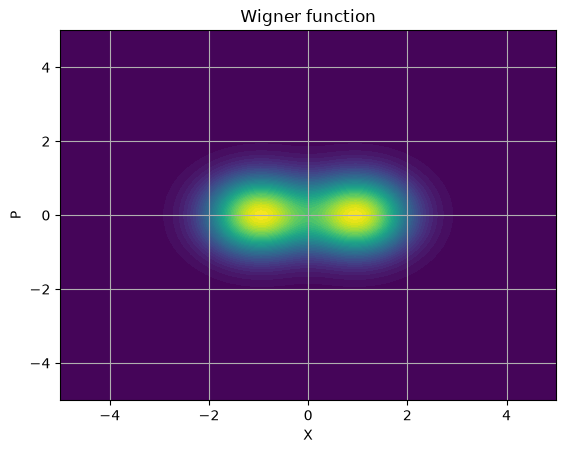

In [42]:
#coherent state from qutip
alpha = 0.7 + 0j
N = 100
coherent_state1 = qt.coherent(N, alpha)
coherent_state2 = qt.coherent(N, -alpha)
#plot in phase space
fig, ax = plt.subplots()
coherent_wigner1 = qt.wigner(coherent_state1, np.linspace(-5, 5, 100), np.linspace(-5, 5, 100))
coherent_wigner2 = qt.wigner(coherent_state2, np.linspace(-5, 5, 100), np.linspace(-5, 5, 100))
sum_wigner = coherent_wigner1 + coherent_wigner2
ax.contourf(np.linspace(-5, 5, 100), np.linspace(-5, 5, 100), sum_wigner, 50)
ax.set_xlabel('X')
ax.set_ylabel('P')
ax.set_title('Wigner function')
ax.grid()

Minimum error prob
$$
P_H = \cfrac12 \left( 1- \sqrt{1-|\langle\alpha |\beta \rangle|^2} \right)
$$

In [43]:
def min_error_prob(coherent_state1, coherent_state2):
    # Calculate the overlap between the two coherent states
    overlap = np.abs(coherent_state1.overlap(coherent_state2))**2
    # Calculate the minimum error probability using the Helstrom bound
    min_error_prob = 0.5 * (1 - np.sqrt(1 - overlap))
    return min_error_prob
P_H = min_error_prob(coherent_state1, coherent_state2)
print(f'Minimum error probability: {P_H:.4f}')

Minimum error probability: 0.0366


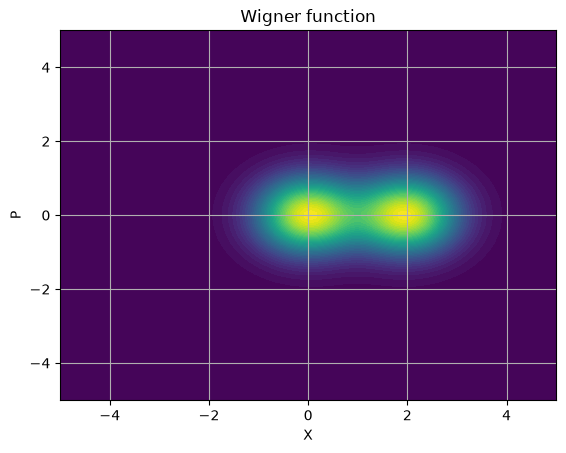

In [44]:
displace_alpha = qt.displace(N, alpha)
coherent_state1_displaced = displace_alpha * coherent_state1
coherent_state2_displaced = displace_alpha * coherent_state2
fig, ax = plt.subplots()
coherent_wigner1 = qt.wigner(coherent_state1_displaced, np.linspace(-5, 5, 100), np.linspace(-5, 5, 100))
coherent_wigner2 = qt.wigner(coherent_state2_displaced, np.linspace(-5, 5, 100), np.linspace(-5, 5, 100))
sum_wigner = coherent_wigner1 + coherent_wigner2
ax.contourf(np.linspace(-5, 5, 100), np.linspace(-5, 5, 100), sum_wigner, 50)
ax.set_xlabel('X')
ax.set_ylabel('P')
ax.set_title('Wigner function')
ax.grid()


In [ ]:
def extract_alpha(coherent_state):
    a = qt.destroy(N)
    extracted_alpha = (coherent_state.dag() * a * coherent_state)
    return extracted_alpha

def kennedy_receiver(coherent1, coherent2):
    #extract alpha from coherent state
    alpha1 = extract_alpha(coherent1)
    #displace states by -alpha1
    displaced1 = qt.displace(N, -alpha1) * coherent1
    displaced2 = qt.displace(N, -alpha1) * coherent2


# coherent_state1 = qt.coherent(N, alpha)
# coherent_state2 = qt.coherent(N, -alpha)
# measurement, total_state = kennedy_receiver(coherent_state1, coherent_state2)

# fig, ax = plt.subplots()
# ax.contourf(np.linspace(-5, 5, 100), np.linspace(-5, 5, 100), total_state, 50)
# ax.set_xlabel('X')
# ax.set_ylabel('P')
# ax.set_title('Wigner function')
# ax.grid()




AttributeError: module 'qutip' has no attribute 'measure'